script for scores:
- subdf with the top20 scores
- take mean, weighted mean, multiplication (prod) and add to df
- calculate roc,pr,fr... improve? ja/ nein

TOP20: ['chai_constrained_interface_iptm', 'boltz_template_per_chain_pair_iptm', 'boltz_free_confidence_score', 'boltz_template_iptm', 'esmfold_ptm', 'boltz_free_per_chain_pair_iptm', 'boltz_free_iptm', 'boltz_free_pde', 'boltz_template_confidence_score', 'boltz_free_iplddt', 'boltz_template_iplddt', 'chai_unconstrained_per_chain_iptm', 'boltz_free_plddt', 'boltz_template_ptm', 'chai_unconstrained_ptm', 'cf_ipsae', 'chai_unconstrained_aggregate_score', 'chai_unconstrained_score', 'chai_unconstrained_iptm', 'boltz_free_ptm']

In [32]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

CSV_PATH = Path("/home/bri/pymol/EDA/static/scores2combine.csv")
df = pd.read_csv(CSV_PATH)

OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/top_scores")
OUTPUT_DIR.mkdir(exist_ok=True)

In [33]:
df.head(10)

,source,type,binder,KD[M],EC50[M],sample,iteration,chai_constrained_per_chain_iptm,chai_unconstrained_per_chain_iptm,chai_constrained_ipsae,...,pred_ilddt,cf_pyros_binder_score,esmfold_iplddt,af3_ptm,cf_interface_dG,pred_lddt,af3_iptm,af3_interface_dG_SASA_ratio,esmfold_ipae,cf_interface_dG_SASA_ratio
0,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-609,0,0.758631,0.171786,0.828829,...,0.748635,8540.50,NaN,0.865,12758.58,0.785100,0.85,1.51,NaN,648.33
1,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-601,0,0.598787,0.147295,0.531820,...,0.674744,65086.93,NaN,0.855,59596.57,0.836655,0.84,1.99,NaN,1855.74
2,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_25-609,0,0.682429,0.255400,0.644171,...,0.063003,41598.65,63.759457,0.820,5122.40,0.854591,0.16,10.06,25.502985,538.75
3,mcmahon,original,1,2.300000e-06,NaN,Nb.AQ100_Adiponectin,0,0.256621,0.159133,0.163092,...,0.130693,26952.43,56.575943,0.840,12945.00,0.837152,0.20,11.33,19.922088,596.82
4,mcmahon,original,0,NaN,NaN,Nb.AQ101_Adiponectin,0,0.326672,0.171685,0.201847,...,0.111693,15987.81,46.311729,0.840,16936.52,0.835296,0.18,3.01,19.643538,788.40
5,mcmahon,original,0,NaN,NaN,Nb.AQ102_Adiponectin,0,0.582322,0.238288,0.475568,...,0.120370,16335.52,52.373833,0.855,23655.01,0.837363,0.15,15.39,19.599617,1036.81
6,mcmahon,original,1,5.100000e-07,NaN,Nb.AQ103_Adiponectin,0,0.330226,0.218349,0.235164,...,0.102869,18606.78,NaN,0.825,18251.20,0.830762,0.17,11.66,NaN,835.37
7,mcmahon,original,0,NaN,NaN,Nb.AQ104_Adiponectin,0,0.255097,0.141926,0.142033,...,0.110993,307.39,50.281277,0.840,717.02,0.890570,0.22,11.63,18.096212,58.12
8,mcmahon,original,0,NaN,NaN,Nb.AD101_A2AR,0,0.301646,0.242299,0.201931,...,0.457820,11364.54,49.020782,0.780,3928.07,0.806944,0.47,22.78,15.536882,343.50
9,mcmahon,original,0,NaN,NaN,Nb.AD102_A2AR,0,0.422356,0.157157,0.333846,...,0.033561,4979.12,49.552746,0.775,11181.02,0.786901,0.25,13.93,19.833744,587.70


In [34]:
# normalize scores to 0-1 range (higher = better) --> actually not that good
# use standard scaler

from sklearn.preprocessing import StandardScaler
cols_to_combine = ['chai_constrained_ipsae', 'cf_ipsae'] # they are both between 0-1 --> not necessary, but we can do standard scaling to center them around 0 and have unit variance
df_norm = pd.DataFrame(df[cols_to_combine], columns=cols_to_combine)
# standard scaler
#scaler = StandardScaler()
#df_norm = pd.DataFrame(scaler.fit_transform(df[cols_to_combine]), columns=cols_to_combine)

df_norm.head()

# NOTE — normalization for ML (future):
#   Scale does not matter for ROC-AUC but will matter for ML models.
#   At that point use QuantileTransformer fit on training data only:
#       qt.fit(X_train[score_cols])
#       X_train_norm = qt.transform(X_train[score_cols])
#       X_test_norm  = qt.transform(X_test[score_cols])  # NOT fit_transform!

,chai_constrained_ipsae,cf_ipsae
0,0.828829,0.717862
1,0.531820,0.713582
2,0.644171,0.538915
3,0.163092,0.370364
4,0.201847,0.244249


In [35]:
# Mean
df['Mean_Score'] = df_norm.mean(axis=1)

df.head()

,source,type,binder,KD[M],EC50[M],sample,iteration,chai_constrained_per_chain_iptm,chai_unconstrained_per_chain_iptm,chai_constrained_ipsae,...,cf_pyros_binder_score,esmfold_iplddt,af3_ptm,cf_interface_dG,pred_lddt,af3_iptm,af3_interface_dG_SASA_ratio,esmfold_ipae,cf_interface_dG_SASA_ratio,Mean_Score
0,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-609,0,0.758631,0.171786,0.828829,...,8540.50,NaN,0.865,12758.58,0.785100,0.85,1.51,NaN,648.33,0.773346
1,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-601,0,0.598787,0.147295,0.531820,...,65086.93,NaN,0.855,59596.57,0.836655,0.84,1.99,NaN,1855.74,0.622701
2,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_25-609,0,0.682429,0.255400,0.644171,...,41598.65,63.759457,0.820,5122.40,0.854591,0.16,10.06,25.502985,538.75,0.591543
3,mcmahon,original,1,2.300000e-06,NaN,Nb.AQ100_Adiponectin,0,0.256621,0.159133,0.163092,...,26952.43,56.575943,0.840,12945.00,0.837152,0.20,11.33,19.922088,596.82,0.266728
4,mcmahon,original,0,NaN,NaN,Nb.AQ101_Adiponectin,0,0.326672,0.171685,0.201847,...,15987.81,46.311729,0.840,16936.52,0.835296,0.18,3.01,19.643538,788.40,0.223048


In [36]:
# Product (Geometric approach)
df['Product_Score'] = df_norm.prod(axis=1)
df.head()

,source,type,binder,KD[M],EC50[M],sample,iteration,chai_constrained_per_chain_iptm,chai_unconstrained_per_chain_iptm,chai_constrained_ipsae,...,esmfold_iplddt,af3_ptm,cf_interface_dG,pred_lddt,af3_iptm,af3_interface_dG_SASA_ratio,esmfold_ipae,cf_interface_dG_SASA_ratio,Mean_Score,Product_Score
0,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-609,0,0.758631,0.171786,0.828829,...,NaN,0.865,12758.58,0.785100,0.85,1.51,NaN,648.33,0.773346,0.594985
1,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-601,0,0.598787,0.147295,0.531820,...,NaN,0.855,59596.57,0.836655,0.84,1.99,NaN,1855.74,0.622701,0.379497
2,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_25-609,0,0.682429,0.255400,0.644171,...,63.759457,0.820,5122.40,0.854591,0.16,10.06,25.502985,538.75,0.591543,0.347153
3,mcmahon,original,1,2.300000e-06,NaN,Nb.AQ100_Adiponectin,0,0.256621,0.159133,0.163092,...,56.575943,0.840,12945.00,0.837152,0.20,11.33,19.922088,596.82,0.266728,0.060403
4,mcmahon,original,0,NaN,NaN,Nb.AQ101_Adiponectin,0,0.326672,0.171685,0.201847,...,46.311729,0.840,16936.52,0.835296,0.18,3.01,19.643538,788.40,0.223048,0.049301


In [37]:
df.to_csv("score_combi_test.csv")

In [39]:
df.head()


,source,type,binder,KD[M],EC50[M],sample,iteration,chai_constrained_per_chain_iptm,chai_unconstrained_per_chain_iptm,chai_constrained_ipsae,...,esmfold_iplddt,af3_ptm,cf_interface_dG,pred_lddt,af3_iptm,af3_interface_dG_SASA_ratio,esmfold_ipae,cf_interface_dG_SASA_ratio,Mean_Score,Product_Score
0,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-609,0,0.758631,0.171786,0.828829,...,NaN,0.865,12758.58,0.785100,0.85,1.51,NaN,648.33,0.773346,0.594985
1,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-601,0,0.598787,0.147295,0.531820,...,NaN,0.855,59596.57,0.836655,0.84,1.99,NaN,1855.74,0.622701,0.379497
2,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_25-609,0,0.682429,0.255400,0.644171,...,63.759457,0.820,5122.40,0.854591,0.16,10.06,25.502985,538.75,0.591543,0.347153
3,mcmahon,original,1,2.300000e-06,NaN,Nb.AQ100_Adiponectin,0,0.256621,0.159133,0.163092,...,56.575943,0.840,12945.00,0.837152,0.20,11.33,19.922088,596.82,0.266728,0.060403
4,mcmahon,original,0,NaN,NaN,Nb.AQ101_Adiponectin,0,0.326672,0.171685,0.201847,...,46.311729,0.840,16936.52,0.835296,0.18,3.01,19.643538,788.40,0.223048,0.049301


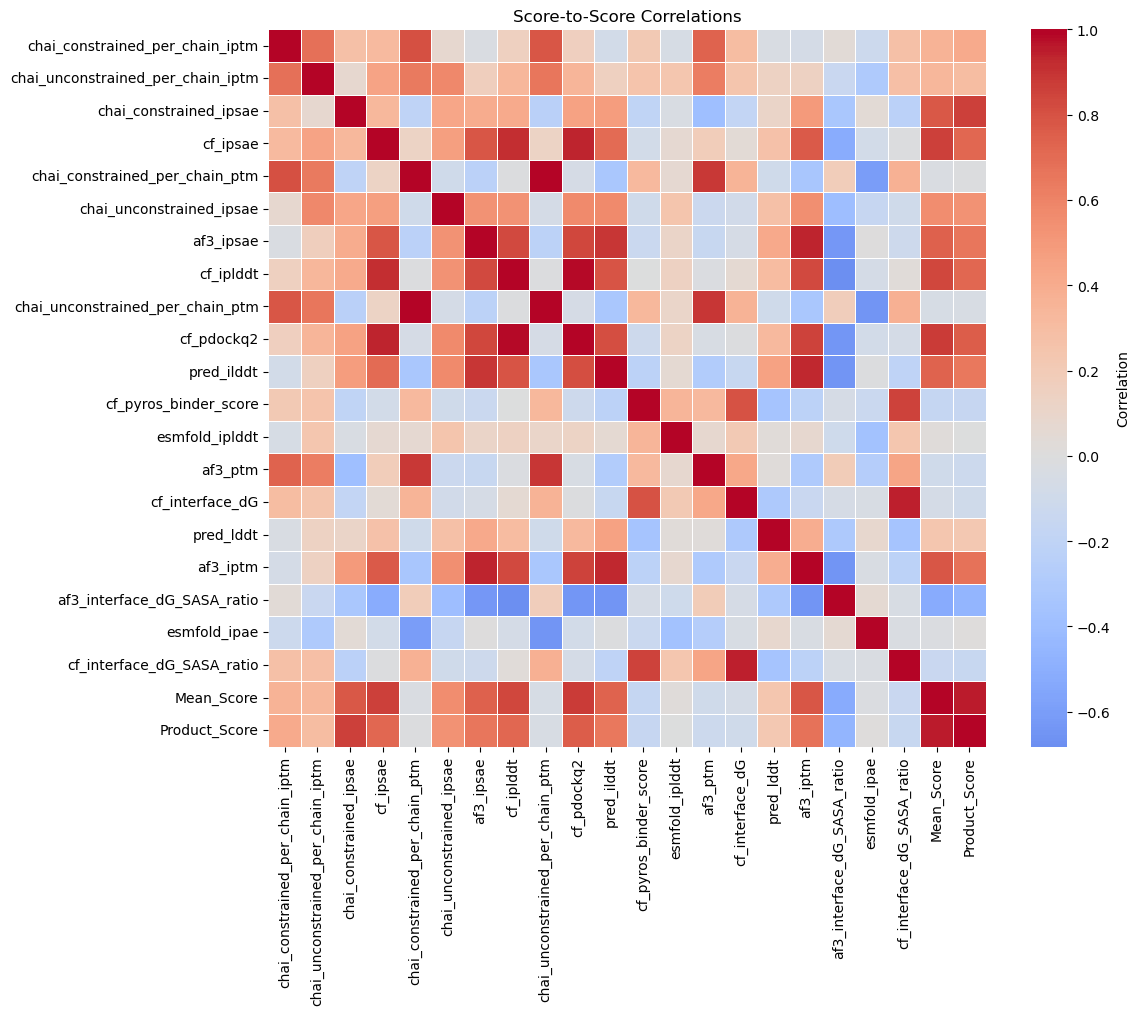

<Figure size 640x480 with 0 Axes>

In [40]:
# directions!!!!!
# Create numeric df and drop binder column
scores_df = pd.read_csv("score_combi_test.csv")
numeric_df = scores_df.select_dtypes(include=[np.number])
numeric_df = numeric_df.dropna(axis=1, how='all')
numeric_df = numeric_df.drop('binder', axis=1, errors='ignore')
numeric_df = numeric_df.drop('KD[M]', axis=1, errors='ignore')
numeric_df = numeric_df.drop('EC50[M]', axis=1, errors='ignore')
numeric_df = numeric_df.drop('iteration', axis=1, errors='ignore')
numeric_df = numeric_df.drop('Unnamed: 0', axis=1, errors='ignore')


# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Score-to-Score Correlations')
plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR / 'score_correlation_heatmap.png', dpi=150, bbox_inches='tight')


In [41]:
# read metric_directions.yaml
from pathlib import Path
import yaml

YAML_PATH =  Path("/home/bri/pymol/EDA/static/metric_directions.yaml")

if Path(YAML_PATH).exists():
    with open(YAML_PATH, 'r') as f:
        yaml_data = yaml.safe_load(f)
    
    # Extract directions
    raw_directions = {k: v['direction'] for k, v in yaml_data['metrics'].items()}
    metric_directions = dict(sorted(raw_directions.items(), key=lambda x: len(x[0]), reverse=True))
    print(f"Loaded {len(metric_directions)} metric directions from YAML.")
else:
    print(f"WARNING: YAML not found at {YAML_PATH}. Using default direction (+1).")
    metric_directions = {}

def get_direction(col_name):
    for base_metric, direction in metric_directions.items():
        if base_metric in col_name: 
            return direction
    return 1

Loaded 58 metric directions from YAML.


In [42]:
import numpy as np
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, 
    auc as auc_pr, average_precision_score, f1_score
)

def calculate_all_metrics(df_data, numeric_cols):
    """
    Calculate comprehensive metrics for each predictor using domain knowledge from YAML.

    Uses get_direction() to determine metric direction from YAML file.
    
    Parameters:
    -----------
    df_data : DataFrame
        Data containing 'binder' column (target) and score columns
    numeric_cols : list
        List of metric column names to evaluate
    
    Returns:
    --------
    DataFrame with columns: metric, raw_roc, aligned_roc, pr_auc, f1, avg_precision, note
    """
    results = []
    
    for col in numeric_cols:
        # Skip if insufficient data
        if df_data[col].notna().sum() < 2 or df_data[col].nunique() < 2:
            continue
        
        try:
            # Clean data
            clean_data = df_data[[col, 'binder']].dropna()
            if clean_data['binder'].nunique() < 2:
                continue
            
            y_true = clean_data['binder'].astype(int)
            y_score_raw = clean_data[col].values
            

            # Step 1: Calculate Raw ROC-AUC
            raw_roc = roc_auc_score(y_true, y_score_raw)
            
            # Step 2: Get direction from YAML (domain knowledge)
            direction = get_direction(col)
            
            # Step 3: Align scores (Higher is always better)
            aligned_scores = y_score_raw * direction
            aligned_roc = max(raw_roc, 1 - raw_roc)
            
            # Step 4: Calculate PR-AUC (Average Precision)
            pr_auc = average_precision_score(y_true, aligned_scores)
            
            # Step 5: PR curve + optimal threshold from PR/F1
            precisions, recalls, thr = precision_recall_curve(y_true, aligned_scores)

            # thresholds correspond to precisions[:-1] and recalls[:-1]
            f1_scores = (
                2 * precisions[:-1] * recalls[:-1]
            ) / (
                precisions[:-1] + recalls[:-1] + 1e-8
            )

            best_idx = np.argmax(f1_scores)

            best_threshold = thr[best_idx]

            y_pred = (aligned_scores >= best_threshold).astype(int)
            max_f1 = f1_score(y_true, y_pred)

            precision = precisions[:-1][best_idx]
            recall = recalls[:-1][best_idx]
            
            
            results.append({
                'metric': col,
                'raw_roc': round(raw_roc, 4),
                'aligned_roc': round(aligned_roc, 4),
                'pr_auc': round(pr_auc, 4),
                'f1': round(max_f1, 4),
                'precision': round(precision, 4),
                'recall': round(recall, 4),
                'opt_threshold': thr[best_idx] * direction,
                'direction': direction,
            })
        except Exception as e:
            continue
    
    # Create df and sort by PR-AUC
    results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
    return results_df

In [43]:
all_iteration_results = []

exclude_cols = ['KD[M]', 'EC50[M]']  # columns to exclude
numeric_cols = scores_df.select_dtypes(include=['number']).columns.tolist()

for i in range(6):
    # Slice the data for the current iteration
    iteration_subset = scores_df[scores_df['iteration'] == i]
    # run function on subsets
    res = calculate_all_metrics(iteration_subset, numeric_cols)
    
    # tag and store
    res['iteration'] = i
    all_iteration_results.append(res)

# Combine all 10 dfs
long_results = pd.concat(all_iteration_results).reset_index(drop=True)
long_results.to_csv(OUTPUT_DIR / 'rankings.csv', index=False)

print(long_results.shape[0])
print("="*100)
print("Metric Evaluation")
print("="*100)
print(long_results.head(20).to_string(index=False))
print("\nSaved to: rankings.csv")

138
Metric Evaluation
                           metric  raw_roc  aligned_roc  pr_auc     f1  precision  recall  opt_threshold  direction  iteration
  chai_constrained_per_chain_iptm   0.7098       0.7098  0.4891 0.5000     0.3553  0.8438       0.306224          1          0
                       Mean_Score   0.6419       0.6419  0.4338 0.4950     0.3623  0.7812       0.502488          1          0
                    Product_Score   0.6378       0.6378  0.4322 0.4578     0.3725  0.5938       0.290426          1          0
                         cf_ipsae   0.6547       0.6547  0.4282 0.4835     0.3729  0.6875       0.686116          1          0
chai_unconstrained_per_chain_iptm   0.6993       0.6993  0.4160 0.4878     0.3846  0.6667       0.232340          1          0
           chai_constrained_ipsae   0.5765       0.5765  0.4104 0.4270     0.3333  0.5938       0.438546          1          0
         chai_unconstrained_ipsae   0.5261       0.5261  0.3529 0.4076     0.2560  1.0000

In [44]:
# Group by the metric name and calculate mean and std for the numeric columns
stats_df = long_results.groupby('metric').agg({
    'raw_roc': ['mean', 'std'],
    'aligned_roc': ['mean', 'std'],
    'pr_auc': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'direction': ['mean'],
    'opt_threshold': ['mean'],
})

# Flatten the multi-index columns
stats_df.columns = [f"{col[0]}_{col[1]}" for col in stats_df.columns]
stats_df = stats_df.reset_index()

# Sort by the average PR-AUC
stats_df = stats_df.sort_values('pr_auc_mean', ascending=False)
stats_df.head()

,metric,raw_roc_mean,raw_roc_std,aligned_roc_mean,aligned_roc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,direction_mean,opt_threshold_mean
14,chai_constrained_per_chain_iptm,0.735333,0.031214,0.735333,0.031214,0.529933,0.069158,0.534450,0.031385,0.506650,0.135303,0.630217,0.147123,1.0,0.464032
0,Mean_Score,0.670333,0.034180,0.670333,0.034180,0.460317,0.061461,0.521350,0.017696,0.385100,0.017240,0.807283,0.012778,1.0,0.486632
1,Product_Score,0.665367,0.038497,0.665367,0.038497,0.459483,0.064863,0.491067,0.020103,0.371633,0.042213,0.760400,0.150063,1.0,0.197925
17,chai_unconstrained_per_chain_iptm,0.741283,0.029532,0.741283,0.029532,0.450100,0.063261,0.539150,0.033305,0.451600,0.068407,0.688917,0.075030,1.0,0.243041
13,chai_constrained_ipsae,0.601067,0.049904,0.601067,0.049904,0.429850,0.068376,0.445833,0.021357,0.341283,0.038106,0.677100,0.160145,1.0,0.389469


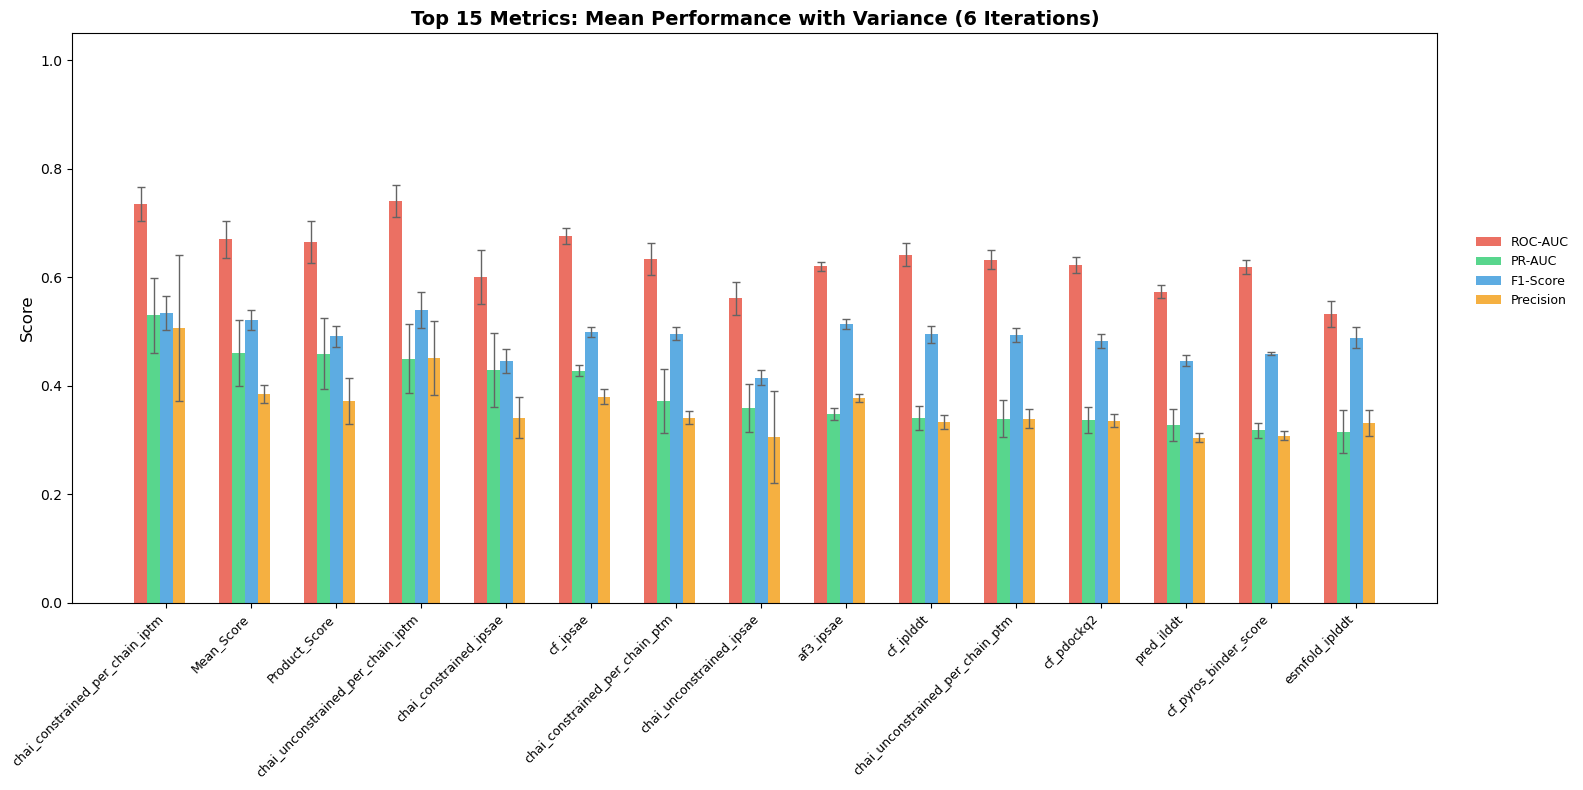

In [53]:
import matplotlib.pyplot as plt

# top 15 based on the mean PR-AUC
top_15 = stats_df.head(15).copy()

fig, ax = plt.subplots(figsize=(16, 8))
x_pos = range(len(top_15))
width = 0.15

metrics_to_plot = [
    ('aligned_roc', 'ROC-AUC', '#e74c3c'),
    ('pr_auc', 'PR-AUC', '#2ecc71'),
    ('f1', 'F1-Score', '#3498db'),
    ('precision', 'Precision', '#f39c12'),
    #('recall', 'Recall', '#9b59b6')
]

# plot each metric with its error bars
for i, (col, label, color) in enumerate(metrics_to_plot):
    # Calculate offset for grouped bar
    offset = (i - 2) * width 
    
    ax.bar(
        [p + offset for p in x_pos], 
        top_15[f'{col}_mean'], 
        width, 
        yerr=top_15[f'{col}_std'], # var
        label=label, 
        color=color, 
        alpha=0.8,
        capsize=3,
        error_kw={'elinewidth': 1, 'ecolor': "#646464"}
    )

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Top 15 Metrics: Mean Performance with Variance (6 Iterations)', 
             fontsize=14, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(top_15['metric'], rotation=45, ha='right', fontsize=9)

# Place legend outside to the right
ax.legend(fontsize=9, loc='lower left', bbox_to_anchor=(1.02, 0.5), frameon=False)

ax.set_ylim([0, 1.05]) # room for error bars
ax.grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top15_metrics_variance.png', dpi=150, bbox_inches='tight')
plt.show()

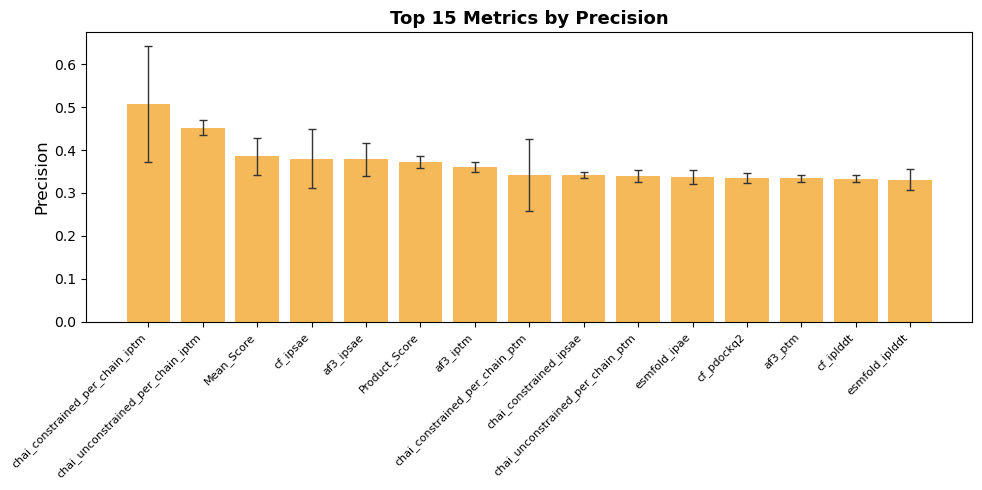

In [54]:
# rearrange rankings by precision
sorted_precision = stats_df.sort_values('precision_mean', ascending=False)   

# plot top15 precision
fig, ax = plt.subplots(figsize=(10, 5)) 
top_15_precision = sorted_precision.head(15)
ax.bar(top_15_precision['metric'], top_15_precision['precision_mean'], color='#f39c12', alpha=0.7, yerr=top_15[f'{col}_std'], capsize=3, error_kw={'elinewidth': 1, 'ecolor': '#333333'})
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Top 15 Metrics by Precision', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(top_15_precision)))
ax.set_xticklabels(top_15_precision['metric'], rotation=45, ha='right', fontsize=8)
ax.grid(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top15_precision.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
import plotly.graph_objects as go


top_20 = stats_df.sort_values(by='pr_auc_mean', ascending=False).head(20)

m1_info, m2_info = top_20.iloc[0], top_20.iloc[2]

m1, t1, d1 = m1_info['metric'], m1_info['opt_threshold_mean'], m1_info['direction_mean']
m2, t2, d2 = m2_info['metric'], m2_info['opt_threshold_mean'], m2_info['direction_mean']

plot_df = (
    scores_df
    .groupby(['source', 'sample', 'type', 'binder'])[[m1, m2]]
    .agg(['mean', 'std'])
    .reset_index()
)

plot_df.columns = [
    f"{c[0]}_{c[1]}" if c[1] else c[0]
    for c in plot_df.columns
]


colors_map = {
    'germinal': "#2ecc71",
    'mcmahon': "#d6a439",
    'snir_ab': "#1f3397"
}

marker_map = {
    0: 'x',
    1: 'circle'
}



alpha_map = {
    "target_shuffle": 0.4,
    "original": 1.0,
    "alanine_scan": 1.0
}

# figure setup

fig = go.Figure()

# loop by type so opacity is consistent
for t, type_df in plot_df.groupby("type"):

    opacity = alpha_map.get(t, 1.0)

    # then split by source + binder
    for (source, binder), subdf in type_df.groupby(["source", "binder"]):

        fig.add_trace(
            go.Scatter(
                x=subdf[f"{m1}_mean"],
                y=subdf[f"{m2}_mean"],

                mode='markers',
                
                marker=dict(
                    color=colors_map[source],
                    symbol=marker_map[binder],
                    size=8,
                    opacity=opacity,
                    line=dict(width=0)
                ),

                name=f"{source} | {t} | binder={binder}",

                text=subdf["sample"],

                hovertemplate=(
                    "<b>%{text}</b><br>"
                    f"{m1}: %{{x:.3f}}<br>"
                    f"{m2}: %{{y:.3f}}<br>"
                    f"source: {source}<br>"
                    f"type: {t}<br>"
                    f"binder: {binder}<br>"
                    "<extra></extra>"
                ),

                showlegend=True
            )
        )


# Threshold lines
fig.add_vline(
    x=t1,
    line_dash="dash",
    line_color="black",
    opacity=0.3
)

fig.add_hline(
    y=t2,
    line_dash="dash",
    line_color="black",
    opacity=0.3
)


# Layout
fig.update_layout(
    width=900,
    height=700,
    plot_bgcolor='white',
    title=f"Comparing Metrics: {m1} vs {m2}",
    xaxis_title=f"{m1}<br>(PR-AUC: {m1_info['pr_auc_mean']:.3f})",
    yaxis_title=f"{m2}<br>(PR-AUC: {m2_info['pr_auc_mean']:.3f})",
    legend_title="Source / Type / Binder"
)

fig.show()